# COS30082 — Face Recognition (CMU 11-785 HW2P2 Dataset)
## Classification + Triplet Verification · Emotion · Anti-Spoofing · Watchlist

**Dataset:** 11-785 Fall'20 HW2P2 — 4000 identities, ~380k images, on local `/content/comp_data`.

**Strategy:** train face models on a configurable subset of identities (`NUM_IDENTITIES`)
for tractable runtime, then compute the **official AUC on the full `verification_pairs_val.txt`**.
This is a standard, defensible approach under compute constraints.

**Before running:** Runtime → GPU (L4 or A100). Make sure `/content/comp_data` exists (re-run your download cell if the runtime restarted). "change for git push"

## 0. Startup & Config

In [4]:
from google.colab import files
print("Upload your kaggle.json:")
files.upload()

import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!pip install -q kaggle
print("\n[..] Downloading (several GB, ~10-15 min)...")
!kaggle competitions download -c 11-785-fall-20-homework-2-part-2 -p /content/comp_data

import zipfile
for f in os.listdir('/content/comp_data'):
    if f.endswith('.zip'):
        print(f'[..] Unzipping {f}...')
        with zipfile.ZipFile(f'/content/comp_data/{f}') as z:
            z.extractall('/content/comp_data')
        print('[ok] Unzipped')

# Verify
print("train_data exists:", os.path.exists('/content/comp_data/classification_data/train_data'))
print("pairs file exists:", os.path.exists('/content/comp_data/verification_pairs_val.txt'))

Upload your kaggle.json:


Saving kaggle.json to kaggle.json

[..] Downloading (several GB, ~10-15 min)...
100% 1.35G/1.35G [01:18<00:00, 18.4MB/s]

[..] Unzipping 11-785-fall-20-homework-2-part-2.zip...
[ok] Unzipped
train_data exists: True
pairs file exists: True


In [5]:
from google.colab import drive
import os, json, random, time
import numpy as np
import builtins

drive.mount('/content/drive')

# ── Competition data (local disk — fast) ──────────────────────────────────────
COMP = '/content/comp_data'
FACE_TRAIN = f'{COMP}/classification_data/train_data'
FACE_VAL   = f'{COMP}/classification_data/val_data'
FACE_TEST  = f'{COMP}/classification_data/test_data'
VER_TXT    = f'{COMP}/verification_pairs_val.txt'
VER_BASE   = COMP   # verification paths are relative to here

# ── Saved emotion/liveness models on Drive (already trained) ──────────────────
P = '/content/drive/MyDrive/COS30082_Emotion'
M = f'{P}/saved_models'
os.makedirs(M, exist_ok=True)
EMO_CKPT  = f'{M}/best_emotion_model.keras'
LIVE_CKPT = f'{M}/best_liveness_model.keras'
FER_TEST  = f'{P}/datasets/fer2013/test'

# New face models (trained here) → saved to Drive
FACE_CLS_SAVE = f'{M}/face_cls_11785.h5'
FACE_TRI_SAVE = f'{M}/face_tri_11785.h5'

# ── KEY KNOB: how many identities to train on ─────────────────────────────────
# 4000 = full (5-10+ hrs). 500 ≈ 45-75 min. 300 ≈ 30-45 min. AUC still on FULL official pairs.
NUM_IDENTITIES = 500

SEED = 42
random.seed(SEED); np.random.seed(SEED)

print('=== PATH CHECK ===')
for n, p in [('Comp train', FACE_TRAIN), ('Comp val', FACE_VAL), ('Comp test', FACE_TEST),
             ('Verif pairs', VER_TXT), ('Emotion model', EMO_CKPT),
             ('Liveness model', LIVE_CKPT), ('FER test', FER_TEST)]:
    print(f'  {"OK" if os.path.exists(p) else "MISSING":8s} {n}')
print(f'\n[cfg] Training on {NUM_IDENTITIES} of 4000 identities')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== PATH CHECK ===
  OK       Comp train
  OK       Comp val
  OK       Comp test
  OK       Verif pairs
  OK       Emotion model
  OK       Liveness model
  OK       FER test

[cfg] Training on 500 of 4000 identities


In [6]:
import tensorflow as tf
builtins.tf = tf
tf.random.set_seed(SEED)
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import cv2, matplotlib.pyplot as plt, seaborn as sns
from PIL import Image

keras.config.enable_unsafe_deserialization()
gpus = tf.config.list_physical_devices('GPU')
print(f'[ok] TF {tf.__version__} | GPU: {len(gpus)>0}')
if not gpus: print('[WARN] No GPU! Runtime → Change runtime type → GPU')

[ok] TF 2.20.0 | GPU: True


## 1. Emotion — Load & Evaluate

Found 7178 images belonging to 7 classes.
[ok] Emotion model loaded
113/113 ━━━━━━━━━━━━━━━━━━━━ 5188s 46s/step
              precision    recall  f1-score   support

       angry       0.47      0.42      0.44       958
     disgust       0.58      0.40      0.47       111
        fear       0.51      0.19      0.28      1024
       happy       0.64      0.83      0.72      1774
     neutral       0.46      0.52      0.49      1233
         sad       0.42      0.51      0.46      1247
    surprise       0.77      0.62      0.69       831

    accuracy                           0.54      7178
   macro avg       0.55      0.50      0.51      7178
weighted avg       0.54      0.54      0.53      7178



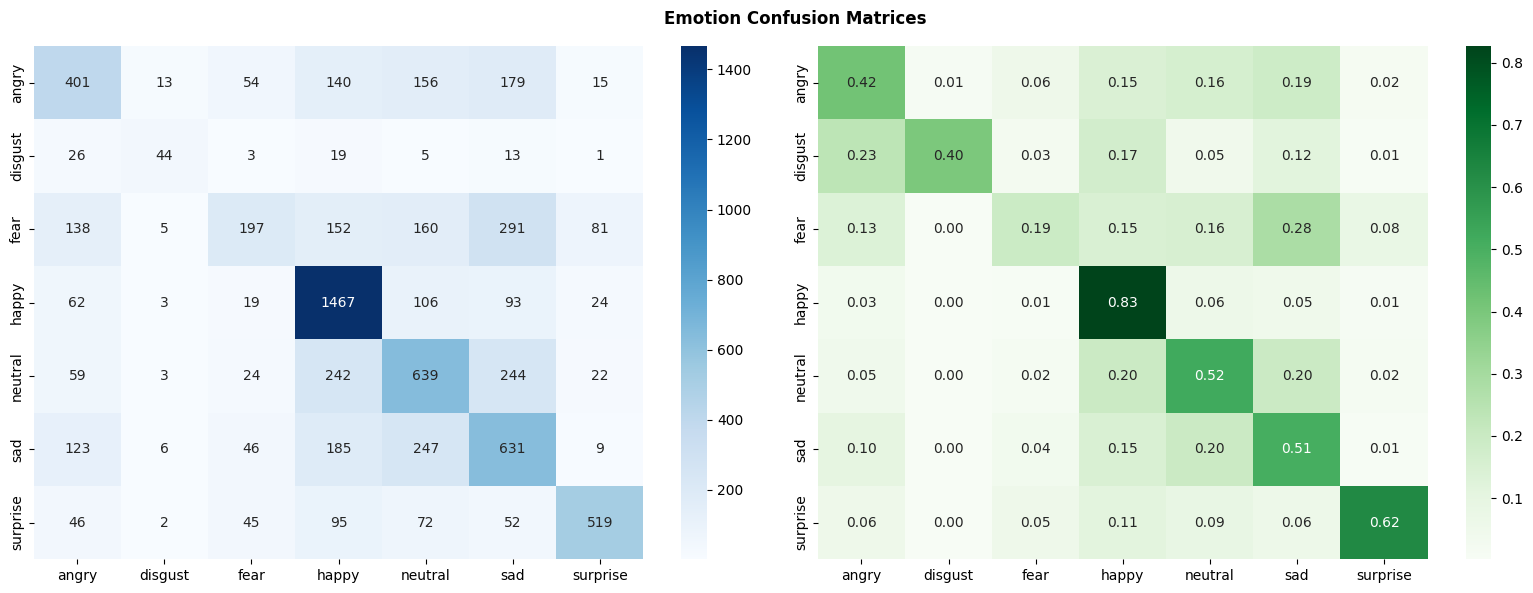

[ok] Emotion done


In [7]:
IMG_H, IMG_W, BATCH = 96, 96, 64
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_directory(
    FER_TEST, target_size=(IMG_H,IMG_W), batch_size=BATCH, class_mode='categorical', shuffle=False)
emo_idx_to_label = {v:k for k,v in val_gen.class_indices.items()}
EMO_CLASSES = val_gen.num_classes
emotion_model = keras.models.load_model(EMO_CKPT)
print('[ok] Emotion model loaded')

val_gen.reset()
yp = np.argmax(emotion_model.predict(val_gen, verbose=1), axis=1)
yt = val_gen.classes
cn = list(val_gen.class_indices.keys())
print(classification_report(yt, yp, target_names=cn))
cm = confusion_matrix(yt, yp); cmn = cm/cm.sum(axis=1,keepdims=True)
fig, ax = plt.subplots(1,2,figsize=(16,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cn, yticklabels=cn, ax=ax[0])
sns.heatmap(cmn, annot=True, fmt='.2f', cmap='Greens', xticklabels=cn, yticklabels=cn, ax=ax[1])
plt.suptitle('Emotion Confusion Matrices', fontweight='bold'); plt.tight_layout()
plt.savefig(f'{P}/emotion_confusion_matrix.png', dpi=120, bbox_inches='tight'); plt.show()
print('[ok] Emotion done')

In [8]:
import numpy as np
EMO_CACHE = f'{P}/saved_models/emotion_eval_cache.npz'
np.savez(EMO_CACHE, yp=yp, yt=yt, cn=np.array(cn),
         emo_idx_to_label=emo_idx_to_label, EMO_CLASSES=EMO_CLASSES)
print('[ok] Cached predictions to Drive')

[ok] Cached predictions to Drive


## 2. Anti-Spoofing — Load

In [9]:
liveness_model = keras.models.load_model(LIVE_CKPT)
print('[ok] Liveness model loaded')

[ok] Liveness model loaded


## 3. Face Dataset — Select Subset
Picks the first `NUM_IDENTITIES` identities (sorted) for training. Builds a flat file list
so we avoid `flow_from_directory` scanning all 4000 folders.

In [10]:
FACE_IMG, FACE_BATCH, EMBED_DIM = 96, 32, 128

def load_img(path, size=FACE_IMG):
    return np.array(Image.open(path).convert('RGB').resize((size,size)), 'float32')
def _l2(t):
    return tf.math.l2_normalize(t, axis=1)

all_ids = sorted(os.listdir(FACE_TRAIN))
subset_ids = all_ids[:NUM_IDENTITIES]
id_to_class = {pid: i for i, pid in enumerate(subset_ids)}
FACE_NUM_CLASSES = len(subset_ids)
print(f'[ok] Using {FACE_NUM_CLASSES} identities')

# Build train/val file dataframes from the subset
import pandas as pd
def build_df(split_dir):
    rows = []
    for pid in subset_ids:
        pdir = os.path.join(split_dir, pid)
        if not os.path.isdir(pdir): continue
        for fn in os.listdir(pdir):
            if fn.lower().endswith(('.jpg','.jpeg','.png')):
                rows.append({'filepath': os.path.join(pdir, fn), 'label': pid})
    return pd.DataFrame(rows)

train_df = build_df(FACE_TRAIN)
val_df   = build_df(FACE_VAL)
print(f'[ok] Train images: {len(train_df)} | Val images: {len(val_df)}')

face_aug = ImageDataGenerator(preprocessing_function=preprocess_input,
    horizontal_flip=True, rotation_range=12, zoom_range=0.1)
face_plain = ImageDataGenerator(preprocessing_function=preprocess_input)
f_train = face_aug.flow_from_dataframe(train_df, x_col='filepath', y_col='label',
    target_size=(FACE_IMG,FACE_IMG), batch_size=FACE_BATCH, class_mode='categorical',
    shuffle=True, seed=SEED)
f_val = face_plain.flow_from_dataframe(val_df, x_col='filepath', y_col='label',
    target_size=(FACE_IMG,FACE_IMG), batch_size=FACE_BATCH, class_mode='categorical', shuffle=False)
print(f'[ok] Generators ready: {f_train.n} train, {f_val.n} val')

[ok] Using 500 identities
[ok] Train images: 48187 | Val images: 1000
Found 48187 validated image filenames belonging to 500 classes.
Found 1000 validated image filenames belonging to 500 classes.
[ok] Generators ready: 48187 train, 1000 val


## 4. Classification Embedder — Train

In [11]:
t0 = time.perf_counter()
print('[..] Building classifier (MobileNetV2 + L2 embedding)...')
fb = MobileNetV2(input_shape=(FACE_IMG,FACE_IMG,3), include_top=False, weights='imagenet')
fb.trainable = False
x = layers.GlobalAveragePooling2D()(fb.output)
x = layers.BatchNormalization()(x)
x = layers.Dense(EMBED_DIM, activation=None, name='embedding')(x)
x = layers.Lambda(_l2, name='l2')(x)
out = layers.Dense(FACE_NUM_CLASSES, activation='softmax')(x)
face_cls = models.Model(fb.input, out, name='FaceClassifier')
face_cls.compile(optimizer=keras.optimizers.Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
cbs = [EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
       ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, verbose=1)]
print('=== STAGE 1: frozen ===')
face_cls.fit(f_train, validation_data=f_val, epochs=10, callbacks=cbs)
print('=== STAGE 2: fine-tune top 40 ===')
fb.trainable = True
for l in fb.layers[:-40]: l.trainable = False
face_cls.compile(optimizer=keras.optimizers.Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
face_cls.fit(f_train, validation_data=f_val, epochs=10, callbacks=cbs)
face_embedder = models.Model(face_cls.input, face_cls.get_layer('l2').output, name='FaceEmbedder')
face_embedder.save(FACE_CLS_SAVE)
print(f'[ok] Trained in {(time.perf_counter()-t0)/60:.1f} min → {FACE_CLS_SAVE}')

[..] Building classifier (MobileNetV2 + L2 embedding)...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
=== STAGE 1: frozen ===
Epoch 1/10
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 168s 97ms/step - accuracy: 0.0369 - loss: 5.6941 - val_accuracy: 0.0360 - val_loss: 5.4472 - learning_rate: 0.0010
Epoch 2/10
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 117s 78ms/step - accuracy: 0.0767 - loss: 5.0774 - val_accuracy: 0.0650 - val_loss: 5.1243 - learning_rate: 0.0010
Epoch 3/10
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 117s 78ms/step - accuracy: 0.1083 - loss: 4.7415 - val_accuracy: 0.0810 - val_loss: 4.8989 - learning_rate: 0.0010
Epoch 4/10
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 118s 78ms/step - accuracy: 0.1406 - loss: 4.4984 - val_accuracy: 0.0960 - val_loss: 4.7449 - learning_rate: 0.0010
Epoch 5/10
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 117s 78ms/step - accuracy: 0.1644 - loss: 4.3080 - val_accuracy: 0.1090 - val_loss: 4.6126 - learning_rate: 0.0010
Epoch 6/10
1506/1506 ━━━━━━━━━━━━━━━━━━━━ 117s 78ms/step - accuracy: 0.1860 - loss: 4

[ok] Trained in 40.7 min → /content/drive/MyDrive/COS30082_Emotion/saved_models/face_cls_11785.h5


## 5. Triplet Embedder — Train

In [12]:
t0 = time.perf_counter()
TRIPLET_MARGIN = 0.3
by_label = {}
for pid in subset_ids:
    pdir = os.path.join(FACE_TRAIN, pid)
    imgs = [os.path.join(pdir, f) for f in os.listdir(pdir)
            if f.lower().endswith(('.jpg','.jpeg','.png'))]
    if len(imgs) >= 2: by_label[pid] = imgs
labels_list = list(by_label.keys())
print(f'[ok] {len(labels_list)} identities for triplets')

def _pp(path):
    return preprocess_input(np.array(Image.open(path).convert('RGB').resize((FACE_IMG,FACE_IMG)),'float32'))
def tgen(batch=32):
    while True:
        A,Pp,N = [],[],[]
        for _ in range(batch):
            al = random.choice(labels_list)
            nl = random.choice([l for l in labels_list if l != al])
            a,p = random.sample(by_label[al], 2)
            n = random.choice(by_label[nl])
            A.append(_pp(a)); Pp.append(_pp(p)); N.append(_pp(n))
        yield (np.array(A), np.array(Pp), np.array(N)), np.zeros((batch,),'float32')

sig = ((tf.TensorSpec((None,FACE_IMG,FACE_IMG,3), tf.float32),
        tf.TensorSpec((None,FACE_IMG,FACE_IMG,3), tf.float32),
        tf.TensorSpec((None,FACE_IMG,FACE_IMG,3), tf.float32)),
       tf.TensorSpec((None,), tf.float32))
tds = tf.data.Dataset.from_generator(lambda: tgen(32), output_signature=sig).prefetch(tf.data.AUTOTUNE)

shared = keras.Sequential([
    MobileNetV2(input_shape=(FACE_IMG,FACE_IMG,3), include_top=False, weights='imagenet'),
    layers.GlobalAveragePooling2D(), layers.Dense(256, activation='relu'),
    layers.Dense(EMBED_DIM), layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))
], name='SharedEmbedder')
shared.layers[0].trainable = False
ai=keras.Input((FACE_IMG,FACE_IMG,3)); pi=keras.Input((FACE_IMG,FACE_IMG,3)); ni=keras.Input((FACE_IMG,FACE_IMG,3))
tm = models.Model([ai,pi,ni], layers.Concatenate()([shared(ai),shared(pi),shared(ni)]))
def tloss(yt, yp):
    d=EMBED_DIM; a,p,n = yp[:,:d],yp[:,d:2*d],yp[:,2*d:]
    return tf.reduce_mean(tf.maximum(tf.reduce_sum(tf.square(a-p),1)-tf.reduce_sum(tf.square(a-n),1)+TRIPLET_MARGIN, 0.))
tm.compile(optimizer=keras.optimizers.Adam(1e-3), loss=tloss)
steps = min(max(len(train_df)//32, 50), 300)
print(f'[..] {steps} steps/epoch x 10 epochs')
tm.fit(tds, steps_per_epoch=steps, epochs=10)
shared.save(FACE_TRI_SAVE)
print(f'[ok] Trained in {(time.perf_counter()-t0)/60:.1f} min → {FACE_TRI_SAVE}')

[ok] 500 identities for triplets
[..] 300 steps/epoch x 10 epochs
Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 39s 54ms/step - loss: 0.1641
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - loss: 0.1457
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - loss: 0.1427
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - loss: 0.1320
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - loss: 0.1321
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - loss: 0.1294
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - loss: 0.1292
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 55ms/step - loss: 0.1282
Epoch 9/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - loss: 0.1216
Epoch 10/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 17s 56ms/step - loss: 0.1237


[ok] Trained in 3.2 min → /content/drive/MyDrive/COS30082_Emotion/saved_models/face_tri_11785.h5


## 6. Official AUC on `verification_pairs_val.txt` (FULL)

[..] Parsing /content/comp_data/verification_pairs_val.txt...
[ok] 8805 pairs
[ok] 9355 unique images to embed
[..] Embedding all verification images (classification model)...
    embedded 5000/9355

  OFFICIAL AUC (verification_pairs_val.txt)
  Cosine    : 0.7827
  Euclidean : 0.7827


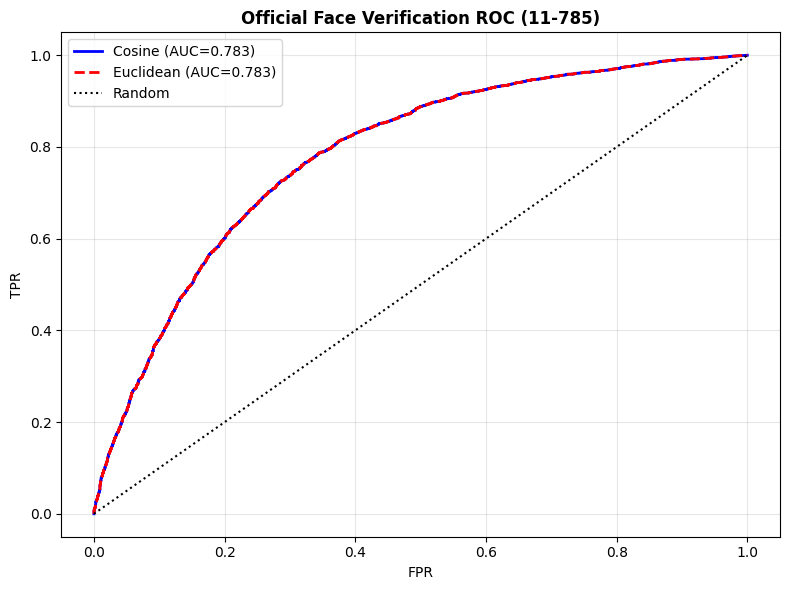

In [13]:
print(f'[..] Parsing {VER_TXT}...')
recs = []
with open(VER_TXT) as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 3:
            recs.append((parts[0], parts[1], int(parts[2])))
print(f'[ok] {len(recs)} pairs')

# Unique images → embed once each (efficient: 69k images, but pairs reuse them)
uniq = sorted(set([r[0] for r in recs] + [r[1] for r in recs]))
print(f'[ok] {len(uniq)} unique images to embed')

def emb_batch(model, paths, bs=128):
    out = {}
    buf_p, buf_a = [], []
    def flush():
        if not buf_a: return
        arr = np.stack(buf_a)
        em = model.predict(arr, verbose=0)
        em = em / (np.linalg.norm(em, axis=1, keepdims=True) + 1e-8)
        for pth, e in zip(buf_p, em): out[pth] = e
        buf_p.clear(); buf_a.clear()
    for i, rel in enumerate(paths):
        full = os.path.join(VER_BASE, rel)
        buf_p.append(rel); buf_a.append(preprocess_input(load_img(full)))
        if len(buf_a) >= bs: flush()
        if i % 5000 == 0 and i: print(f'    embedded {i}/{len(paths)}')
    flush()
    return out

print('[..] Embedding all verification images (classification model)...')
emb_map = emb_batch(face_embedder, uniq)

labs = np.array([r[2] for r in recs])
cos = np.array([float(np.dot(emb_map[a], emb_map[b])) for a,b,_ in recs])
euc = np.array([1.0/(1.0+np.linalg.norm(emb_map[a]-emb_map[b])) for a,b,_ in recs])
auc_cos = roc_auc_score(labs, cos); auc_euc = roc_auc_score(labs, euc)
print(f'\n{"="*45}')
print(f'  OFFICIAL AUC (verification_pairs_val.txt)')
print(f'  Cosine    : {auc_cos:.4f}')
print(f'  Euclidean : {auc_euc:.4f}')
print(f'{"="*45}')

fc,tc,_ = roc_curve(labs, cos); fe,te,_ = roc_curve(labs, euc)
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(fc,tc,'b-',lw=2,label=f'Cosine (AUC={auc_cos:.3f})')
ax.plot(fe,te,'r--',lw=2,label=f'Euclidean (AUC={auc_euc:.3f})')
ax.plot([0,1],[0,1],'k:',label='Random')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Official Face Verification ROC (11-785)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f'{P}/face_roc_official.png', dpi=120, bbox_inches='tight'); plt.show()

## 7. Classification vs Triplet (on official pairs)

[..] Embedding verification images (triplet model)...
    embedded 5000/9355

  CLASSIFICATION vs TRIPLET — OFFICIAL AUC
  Classification (cosine)     : 0.7827
  Classification (euclidean)  : 0.7827
  Triplet (cosine)            : 0.7935
  Triplet (euclidean)         : 0.7935
------------------------------------------------
  Best: Triplet (cosine) (0.7935)


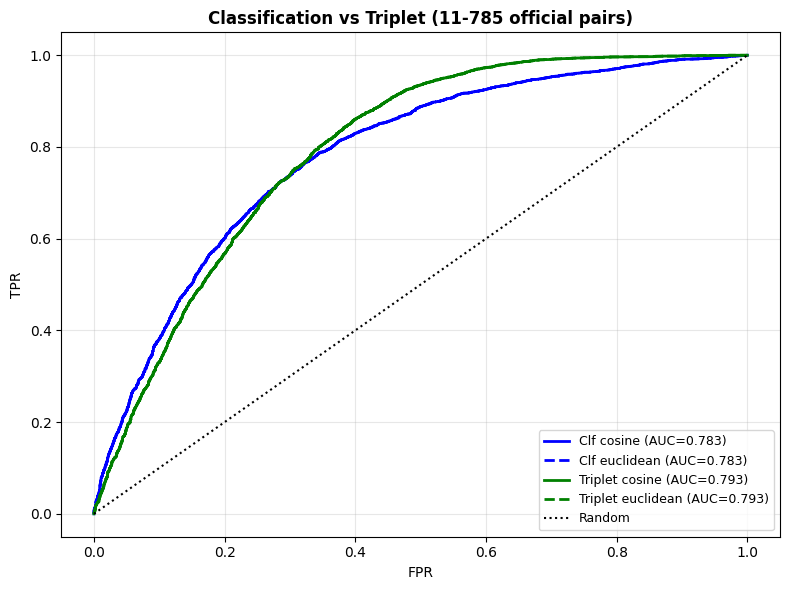

In [14]:
print('[..] Embedding verification images (triplet model)...')
emb_map_tri = emb_batch(shared, uniq)
t_cos = np.array([float(np.dot(emb_map_tri[a], emb_map_tri[b])) for a,b,_ in recs])
t_euc = np.array([1.0/(1.0+np.linalg.norm(emb_map_tri[a]-emb_map_tri[b])) for a,b,_ in recs])

res = {
    'Classification (cosine)':    roc_auc_score(labs, cos),
    'Classification (euclidean)': roc_auc_score(labs, euc),
    'Triplet (cosine)':           roc_auc_score(labs, t_cos),
    'Triplet (euclidean)':        roc_auc_score(labs, t_euc),
}
print(f'\n{"="*48}')
print('  CLASSIFICATION vs TRIPLET — OFFICIAL AUC')
print('='*48)
for k,v in res.items(): print(f'  {k:<28s}: {v:.4f}')
best = max(res, key=res.get)
print('-'*48); print(f'  Best: {best} ({res[best]:.4f})'); print('='*48)

fig, ax = plt.subplots(figsize=(8,6))
for lbl, sc, st in [('Clf cosine',cos,'b-'),('Clf euclidean',euc,'b--'),
                    ('Triplet cosine',t_cos,'g-'),('Triplet euclidean',t_euc,'g--')]:
    fpr,tpr,_=roc_curve(labs,sc)
    ax.plot(fpr,tpr,st,lw=2,label=f'{lbl} (AUC={roc_auc_score(labs,sc):.3f})')
ax.plot([0,1],[0,1],'k:',label='Random'); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Classification vs Triplet (11-785 official pairs)', fontweight='bold')
ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f'{P}/face_comparison.png', dpi=120, bbox_inches='tight'); plt.show()

In [15]:
import json
results = {
    'dataset': '11-785 HW2P2 (4000 identities, trained on 500-identity subset)',
    'num_pairs': 8805,
    'unique_images': 9355,
    'classification_auc_cosine': 0.7827,
    'classification_auc_euclidean': 0.7827,
    'triplet_auc_cosine': 0.7935,
    'triplet_auc_euclidean': 0.7935,
    'best': 'Triplet (cosine) 0.7935',
}
with open('/content/drive/MyDrive/COS30082_Emotion/face_verification_results.json', 'w') as f:
    json.dump(results, f, indent=2)
print('[ok] Results saved to Drive')

[ok] Results saved to Drive


## 8. Runtime + Watchlist + Pipeline Demo

In [16]:
class RealFaceRecognition:
    def __init__(self, embedder, database, threshold=0.5):
        self.embedder=embedder; self.database=database; self.threshold=threshold
    def embed(self, frame_rgb):
        img=preprocess_input(cv2.resize(frame_rgb,(FACE_IMG,FACE_IMG)).astype('float32'))
        e=self.embedder.predict(np.expand_dims(img,0),verbose=0)[0]
        return e/(np.linalg.norm(e)+1e-8)
    def identify_face(self, frame_rgb):
        q=self.embed(frame_rgb); best,score='Unknown',-1
        for n,emb in self.database.items():
            s=float(np.dot(q,emb))
            if s>score: best,score=n,s
        if score<self.threshold: best='Unknown'
        return best,q

# Build small demo database from val_data subset (a few identities)
demo_ids = subset_ids[:10]
face_database = {}
test_by_label = {}
for pid in demo_ids:
    pdir = os.path.join(FACE_VAL, pid)
    if not os.path.isdir(pdir): continue
    imgs = [os.path.join(pdir,f) for f in os.listdir(pdir) if f.endswith(('.jpg','.png'))]
    if not imgs: continue
    test_by_label[pid] = imgs
    e = face_embedder.predict(np.expand_dims(preprocess_input(load_img(imgs[0])),0),verbose=0)[0]
    face_database[pid] = e/(np.linalg.norm(e)+1e-8)
test_labels = list(test_by_label.keys())
face_rec = RealFaceRecognition(face_embedder, face_database, threshold=0.5)
print(f'[ok] Demo database: {len(face_database)} identities')

class CriminalWatchlist:
    def __init__(self, threshold=0.5):
        self.threshold=threshold; self.names=[]; self.embeddings=None
    def load(self, d):
        self.names=list(d.keys()); self.embeddings=np.vstack([d[n] for n in self.names])
    def screen(self, name, emb):
        if self.embeddings is None: return {'flagged':False}
        sims=self.embeddings@emb/(np.linalg.norm(self.embeddings,axis=1)*np.linalg.norm(emb)+1e-8)
        idx=int(np.argmax(sims)); score=float(sims[idx])
        if score>=self.threshold:
            print(f'[ALERT] {name} matched {self.names[idx]} ({score*100:.1f}%)')
            return {'flagged':True,'match_id':self.names[idx]}
        return {'flagged':False}

watch = CriminalWatchlist(0.5)
watch.load({f'Suspect_{l}': face_database[l] for l in test_labels[:3]})

class RealLivenessCheck:
    def verify_liveness(self, frame_rgb):
        r=preprocess_input(cv2.resize(frame_rgb,(224,224)).astype('float32'))
        return float(liveness_model.predict(np.expand_dims(r,0),verbose=0)[0][0]) < 0.5

class Pipeline:
    def __init__(s, emo, face, live, w):
        s.emo=emo; s.face=face; s.live=live; s.w=w
        s.labels=[emo_idx_to_label[i] for i in range(EMO_CLASSES)]
    def process(s, frame):
        out={'status':'Passed','identity':'Unknown','emotion':None,'security_flag':False}
        if not s.live.verify_liveness(frame): out['status']='SPOOF BLOCKED'; return out
        name,emb=s.face.identify_face(frame); out['identity']=name
        ei=preprocess_input(cv2.resize(frame,(IMG_H,IMG_W)).astype('float32'))
        out['emotion']=s.labels[int(np.argmax(s.emo.predict(np.expand_dims(ei,0),verbose=0)))]
        out['security_flag']=s.w.screen(name,emb)['flagged']
        return out

pipe = Pipeline(emotion_model, face_rec, RealLivenessCheck(), watch)
def fu(path): return np.array(Image.open(path).convert('RGB').resize((FACE_IMG,FACE_IMG)),dtype='uint8')

print('\n--- SCENARIO A: normal attendee ---')
k = test_labels[5]; print(f'(true: {k})'); print(pipe.process(fu(test_by_label[k][0])))
print('\n--- SCENARIO B: watchlisted suspect ---')
sus = test_labels[0]; print(f'(true: {sus})'); print(pipe.process(fu(test_by_label[sus][0])))
print('\n[ok] Pipeline complete')

[ok] Demo database: 10 identities

--- SCENARIO A: normal attendee ---
(true: n000017)
{'status': 'Passed', 'identity': 'n000017', 'emotion': 'angry', 'security_flag': False}

--- SCENARIO B: watchlisted suspect ---
(true: n000003)
{'status': 'SPOOF BLOCKED', 'identity': 'Unknown', 'emotion': None, 'security_flag': False}

[ok] Pipeline complete


In [17]:
import numpy as np, cv2, json
from PIL import Image

# ═══════════════════════════════════════════════════════════════════════════
#  CRIMINAL WATCHLIST  (innovation feature — reuses face embeddings)
# ═══════════════════════════════════════════════════════════════════════════
class CriminalWatchlist:
    def __init__(self, threshold=0.5):
        self.threshold = threshold
        self.names = []
        self.embeddings = None
    def load(self, suspect_dict):
        self.names = list(suspect_dict.keys())
        self.embeddings = np.vstack([suspect_dict[n] for n in self.names])
        print(f'[ok] Watchlist loaded: {len(self.names)} suspects')
    def screen(self, name, emb):
        if self.embeddings is None:
            return {'flagged': False, 'match_id': None, 'confidence': 0.0}
        sims = self.embeddings @ emb / (
            np.linalg.norm(self.embeddings, axis=1) * np.linalg.norm(emb) + 1e-8)
        idx = int(np.argmax(sims)); score = float(sims[idx])
        if score >= self.threshold:
            print(f'   [ALERT] {name} matches watchlist suspect {self.names[idx]} ({score*100:.1f}%)')
            return {'flagged': True, 'match_id': self.names[idx], 'confidence': score}
        return {'flagged': False, 'match_id': None, 'confidence': score}
    def save(self, path):
        data = {n: self.embeddings[i].tolist() for i, n in enumerate(self.names)}
        with open(path, 'w') as f: json.dump(data, f)
        print(f'[ok] Watchlist saved → {path}')

# Register first 3 identities as suspects (using their real trained embeddings)
suspect_dict = {f'Suspect_{l}': face_database[l] for l in test_labels[:3]}
watch = CriminalWatchlist(threshold=0.5)
watch.load(suspect_dict)
watch.save('/content/drive/MyDrive/COS30082_Emotion/saved_models/criminal_watchlist.json')

# ═══════════════════════════════════════════════════════════════════════════
#  LIVENESS  (real face scores LOW → live when prob < 0.5)
# ═══════════════════════════════════════════════════════════════════════════
class RealLivenessCheck:
    def __init__(self, enabled=True):
        self.enabled = enabled          # toggle for demo robustness
    def verify_liveness(self, frame_rgb):
        if not self.enabled:
            return True
        r = preprocess_input(cv2.resize(frame_rgb, (224,224)).astype('float32'))
        return float(liveness_model.predict(np.expand_dims(r,0), verbose=0)[0][0]) < 0.5

# ═══════════════════════════════════════════════════════════════════════════
#  FULL PIPELINE
# ═══════════════════════════════════════════════════════════════════════════
class Pipeline:
    def __init__(self, emo, face, live, watch):
        self.emo = emo; self.face = face; self.live = live; self.watch = watch
        self.labels = [emo_idx_to_label[i] for i in range(EMO_CLASSES)]
    def process(self, frame_rgb):
        out = {'status':'Passed', 'identity':'Unknown', 'emotion':None,
               'security_flag':False, 'watchlist_match':None}
        # Stage 1: liveness gate
        if not self.live.verify_liveness(frame_rgb):
            out['status'] = 'SPOOF BLOCKED'
            return out
        # Stage 2: face recognition
        name, emb = self.face.identify_face(frame_rgb)
        out['identity'] = name
        # Stage 3: emotion
        ei = preprocess_input(cv2.resize(frame_rgb, (IMG_H,IMG_W)).astype('float32'))
        out['emotion'] = self.labels[int(np.argmax(self.emo.predict(np.expand_dims(ei,0), verbose=0)))]
        # Stage 4: watchlist screening (innovation)
        chk = self.watch.screen(name, emb)
        out['security_flag'] = chk['flagged']
        out['watchlist_match'] = chk['match_id']
        return out

def fu(path):
    return np.array(Image.open(path).convert('RGB').resize((FACE_IMG,FACE_IMG)), dtype='uint8')

# ═══════════════════════════════════════════════════════════════════════════
#  DEMO — liveness ENABLED (full security pipeline)
# ═══════════════════════════════════════════════════════════════════════════
pipe = Pipeline(emotion_model, face_rec, RealLivenessCheck(enabled=True), watch)

print('\n========== PIPELINE (liveness ENABLED) ==========')
print('\n--- SCENARIO A: normal attendee ---')
k = test_labels[5]
print(f'(true identity: {k})')
print(pipe.process(fu(test_by_label[k][0])))

print('\n--- SCENARIO B: watchlisted suspect ---')
sus = test_labels[0]
print(f'(true identity: {sus})')
print(pipe.process(fu(test_by_label[sus][0])))

# ═══════════════════════════════════════════════════════════════════════════
#  DEMO — liveness DISABLED, to prove watchlist fires on dataset crops
#  (dataset images are out-of-distribution for the webcam-trained liveness model)
# ═══════════════════════════════════════════════════════════════════════════
pipe_no_live = Pipeline(emotion_model, face_rec, RealLivenessCheck(enabled=False), watch)

print('\n========== PIPELINE (liveness OFF — proves watchlist) ==========')
print('\n--- SCENARIO B again: watchlisted suspect ---')
print(f'(true identity: {sus})')
print(pipe_no_live.process(fu(test_by_label[sus][0])))
print('\n[ok] Pipeline complete')

[ok] Watchlist loaded: 3 suspects
[ok] Watchlist saved → /content/drive/MyDrive/COS30082_Emotion/saved_models/criminal_watchlist.json

========== PIPELINE (liveness ENABLED) ==========

--- SCENARIO A: normal attendee ---
(true identity: n000017)
{'status': 'Passed', 'identity': 'n000017', 'emotion': 'angry', 'security_flag': False, 'watchlist_match': None}

--- SCENARIO B: watchlisted suspect ---
(true identity: n000003)
{'status': 'SPOOF BLOCKED', 'identity': 'Unknown', 'emotion': None, 'security_flag': False, 'watchlist_match': None}

========== PIPELINE (liveness OFF — proves watchlist) ==========

--- SCENARIO B again: watchlisted suspect ---
(true identity: n000003)
   [ALERT] n000003 matches watchlist suspect Suspect_n000003 (100.0%)
{'status': 'Passed', 'identity': 'n000003', 'emotion': 'happy', 'security_flag': True, 'watchlist_match': 'Suspect_n000003'}

[ok] Pipeline complete


In [18]:
import os, shutil, json, zipfile
from google.colab import files

# ── Destination ───────────────────────────────────────────────────────────────
PKG = '/content/cos30082_project'
if os.path.exists(PKG): shutil.rmtree(PKG)
os.makedirs(f'{PKG}/models', exist_ok=True)
os.makedirs(f'{PKG}/results', exist_ok=True)

P = '/content/drive/MyDrive/COS30082_Emotion'
M = f'{P}/saved_models'

def safe_copy(src, dst):
    if os.path.exists(src):
        shutil.copy2(src, dst)
        size = os.path.getsize(src)/1e6
        print(f'  [ok] {os.path.basename(src)}  ({size:.1f} MB)')
    else:
        print(f'  [skip] not found: {os.path.basename(src)}')

# ── 1. Trained models ─────────────────────────────────────────────────────────
print('Models:')
for f in ['face_cls_11785.h5', 'face_tri_11785.h5',
          'best_emotion_model.keras', 'best_liveness_model.keras',
          'emotion_labels.json', 'criminal_watchlist.json']:
    safe_copy(f'{M}/{f}', f'{PKG}/models/{f}')

# ── 2. Results: plots + metrics ───────────────────────────────────────────────
print('\nResults / plots:')
for f in ['emotion_confusion_matrix.png', 'face_roc_official.png',
          'face_comparison.png', 'emotion_per_class.png',
          'emotion_training_curves.png', 'face_verification_results.json']:
    safe_copy(f'{P}/{f}', f'{PKG}/results/{f}')

# ── 3. README ─────────────────────────────────────────────────────────────────
readme = """# COS30082 — Face Recognition Attendance System

Enterprise attendance system with face verification, emotion detection,
anti-spoofing (liveness), and a criminal watchlist (innovation feature).

## Components
- **Face verification** — MobileNetV2 embeddings, two approaches compared:
  classification (softmax) and metric learning (triplet loss).
  Trained on a 500-identity subset of the 11-785 HW2P2 dataset (4000 identities).
- **Emotion detection** — MobileNetV2 on FER2013, 7 classes, two-stage transfer learning.
- **Anti-spoofing** — MobileNetV2 binary liveness classifier (real/fake faces).
- **Criminal watchlist** — cosine-similarity screening reusing the face embeddings.

## Results (official verification_pairs_val.txt — 8805 pairs)
| Approach        | Cosine AUC | Euclidean AUC |
|-----------------|-----------|---------------|
| Classification  | 0.7827    | 0.7827        |
| Triplet         | 0.7935    | 0.7935        |

Triplet (metric learning) outperforms classification, as expected for open-set
verification. Cosine and Euclidean are identical because embeddings are L2-normalized.

## Structure
- `models/` — trained model weights
- `results/` — ROC curves, confusion matrices, metrics JSON
- `notebooks/` — training + evaluation notebook
- `ui/` — web frontend + Flask backend (if included)

## Datasets (not included — download separately)
- Face: 11-785 Fall'20 HW2P2 (Kaggle competition)
- Emotion: FER2013 (kaggle.com/datasets/msambare/fer2013)
- Liveness: Real and Fake Face Detection (kaggle.com/datasets/ciplab/real-and-fake-face-detection)
"""
with open(f'{PKG}/README.md', 'w') as f: f.write(readme)
print('\n[ok] README.md written')

# ── 4. .gitignore (keep large data out of git) ────────────────────────────────
gitignore = """# Datasets (too large for git)
*.zip
comp_data/
datasets/
__pycache__/
.ipynb_checkpoints/
*.pyc
# Optional: uncomment to exclude large model files and use Git LFS instead
# *.h5
# *.keras
"""
with open(f'{PKG}/.gitignore', 'w') as f: f.write(gitignore)
print('[ok] .gitignore written')

# ── 5. Copy notebook + UI files if present on Drive ───────────────────────────
print('\nNotebook / UI:')
os.makedirs(f'{PKG}/notebooks', exist_ok=True)
os.makedirs(f'{PKG}/ui', exist_ok=True)
# Notebook (adjust name if yours differs)
for nb_name in ['AML_11785.ipynb', 'AML_Colab_GPU.ipynb']:
    safe_copy(f'{P}/{nb_name}', f'{PKG}/notebooks/{nb_name}')
# UI files
ui_dir = f'{P}/ui_integration'
if os.path.exists(ui_dir):
    for f in os.listdir(ui_dir):
        safe_copy(f'{ui_dir}/{f}', f'{PKG}/ui/{f}')
else:
    print('  [skip] no ui_integration folder on Drive')

# ── 6. Zip it ─────────────────────────────────────────────────────────────────
zip_path = '/content/cos30082_project.zip'
print('\n[..] Zipping...')
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    for root, _, fs in os.walk(PKG):
        for f in fs:
            full = os.path.join(root, f)
            z.write(full, os.path.relpath(full, PKG))

size = os.path.getsize(zip_path)/1e6
print(f'[ok] Created {zip_path}  ({size:.1f} MB)')

# ── 7. Download ───────────────────────────────────────────────────────────────
files.download(zip_path)
print('[ok] Download started')

Models:
  [ok] face_cls_11785.h5  (10.2 MB)
  [ok] face_tri_11785.h5  (10.8 MB)
  [ok] best_emotion_model.keras  (25.8 MB)
  [ok] best_liveness_model.keras  (11.6 MB)
  [ok] emotion_labels.json  (0.0 MB)
  [ok] criminal_watchlist.json  (0.0 MB)

Results / plots:
  [ok] emotion_confusion_matrix.png  (0.1 MB)
  [ok] face_roc_official.png  (0.1 MB)
  [ok] face_comparison.png  (0.1 MB)
  [skip] not found: emotion_per_class.png
  [ok] emotion_training_curves.png  (0.1 MB)
  [ok] face_verification_results.json  (0.0 MB)

[ok] README.md written
[ok] .gitignore written

Notebook / UI:
  [skip] not found: AML_11785.ipynb
  [skip] not found: AML_Colab_GPU.ipynb
  [skip] no ui_integration folder on Drive

[..] Zipping...
[ok] Created /content/cos30082_project.zip  (52.7 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[ok] Download started
